# Modeling - With C1 vs C3 vs C4 possible improvements
Adding new features
`tilt_distance_ratio`
`neighbor_competition =avg_neighbor_advantage *overlap_ratio`
`overlap_sinr_penalty`

In [53]:
import numpy as np
import statsmodels.api as sm

print(np.__version__)
print(sm.__version__)

1.26.4
0.14.6


In [74]:
!pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [54]:
import json
import re
import math
import numpy as np
import pandas as pd
from io import StringIO

## Feature Engineering

In [55]:
def parse_tables(question):
    text = question.replace("\r\n", "\n").replace("\r", "\n")

    user_match = re.search(
        r"User plane drive test data as follows[：:]\s*\n+(.*?)(?:\n\s*\n\s*Engeneering parameters data as follows[：:]|\n\s*\n\s*Engineering parameters data as follows[：:])",
        text,
        flags=re.S
    )

    eng_match = re.search(
        r"(?:Engeneering|Engineering) parameters data as follows[：:]\s*\n+(.*)$",
        text,
        flags=re.S
    )

    if not user_match or not eng_match:
        raise ValueError("Could not find table blocks")

    def block_to_df(block):
        lines = []
        for line in block.splitlines():
            line = line.strip()
            if "|" in line:
                lines.append(line)

        # Repairs rare formatting issue like "g\nNodeB ID"
        if lines and lines[0].startswith("NodeB ID|"):
            lines[0] = "g" + lines[0]

        return pd.read_csv(StringIO("\n".join(lines)), sep="|")

    user_df = block_to_df(user_match.group(1))
    eng_df = block_to_df(eng_match.group(1))

    return user_df, eng_df


def beamwidth_from_scenario(s):
    if pd.isna(s):
        return np.nan

    s = str(s).upper()

    if "DEFAULT" in s:
        return 6

    match = re.search(r"SCENARIO_(\d+)", s)
    if match:
        n = int(match.group(1))
        if n <= 5:
            return 6
        elif n <= 11:
            return 12
        else:
            return 25

    return np.nan

# Calculate distance between vehicle GPS location and tower location
# C2: coverage distance exceeds 1 km -> To calculate distance
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# longest consecutive streak of low throughput
def longest_streak_bool(values):
    max_streak = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak

def make_features(user_df, eng_df):
    # Taking care of missing data "-" as NaN
    user_df = user_df.copy().replace("-", np.nan)
    eng_df = eng_df.copy().replace("-", np.nan)

    # Define important column names
    tp_col = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
    speed_col = "GPS Speed (km/h)"
    # "What cell is the UE connected to?"
    pci_col = "5G KPI PCell RF Serving PCI"
    # "How strong is the signal?"
    rsrp_col = "5G KPI PCell RF Serving SS-RSRP [dBm]"
    # "How clean is the signal?"
    sinr_col = "5G KPI PCell RF Serving SS-SINR [dB]"
    # "How many RBs are being used?"
    rb_col = "5G KPI PCell Layer1 DL RB Num (Including 0)"

    neighbor_pci_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} PCI"
        for i in range(1, 6)
    ]

    neighbor_brsrp_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} Filtered Tx BRSRP [dBm]"
        for i in range(1, 6)
    ]

    numeric_user_cols = [
        "Longitude", "Latitude",
        tp_col, speed_col, pci_col, rsrp_col, sinr_col, rb_col
    ] + neighbor_pci_cols + neighbor_brsrp_cols

    # Convert text numbers into numeric values
    for col in numeric_user_cols:
        if col in user_df.columns:
            user_df[col] = pd.to_numeric(user_df[col], errors="coerce")

    numeric_eng_cols = [
        "Longitude", "Latitude", "Mechanical Downtilt",
        "Digital Tilt", "Height", "PCI"
    ]

    for col in numeric_eng_cols:
        eng_df[col] = pd.to_numeric(eng_df[col], errors="coerce")

    # Engineering transformations
    # we replace 255 with 6.
    eng_df["digital_tilt_clean"] = eng_df["Digital Tilt"].replace(255, 6)
    # effective_tilt = mechanical downtilt + digital tilt -> Can be useful for C1: downtilt too large
    eng_df["effective_tilt"] = (
        eng_df["Mechanical Downtilt"] + eng_df["digital_tilt_clean"]
    )
    eng_df["beamwidth"] = eng_df["Beam Scenario"].apply(beamwidth_from_scenario)

    #print("Engineering data after transformations:")
    #print(eng_df)

    eng_by_pci = (
        eng_df
        .dropna(subset=["PCI"])
        .drop_duplicates("PCI")
        .set_index("PCI")
    )

    features = {}

    tp = user_df[tp_col]
    low_mask = tp < 600
    low_df = user_df[low_mask]

    # -----------------------------
    # Throughput features
    # -----------------------------
    features["avg_throughput"] = tp.mean()
    features["min_throughput"] = tp.min()
    features["std_throughput"] = tp.std()
    features["low_tp_count"] = int(low_mask.sum())
    features["low_tp_ratio"] = low_mask.mean()
    features["avg_throughput_low_tp"] = low_df[tp_col].mean()
    features["consecutive_low_tp_max"] = longest_streak_bool(low_mask.tolist())

    # -----------------------------
    # Speed features
    # -----------------------------
    speed = user_df[speed_col]

    features["max_speed"] = speed.max()
    features["pct_speed_above_40"] = (speed > 40).mean()
    features["avg_speed_low_tp"] = low_df[speed_col].mean()
    features["max_speed_low_tp"] = low_df[speed_col].max()

    # -----------------------------
    # Handover features
    # -----------------------------
    serving_pci = user_df[pci_col]

    features["num_unique_serving_pci"] = serving_pci.nunique()

    switches = (
        (serving_pci != serving_pci.shift())
        & serving_pci.notna()
        & serving_pci.shift().notna()
    )

    features["handover_count"] = int(switches.sum())
    features["handover_rate"] = features["handover_count"] / max(len(user_df) - 1, 1)

    if len(low_df) > 1:
        low_pci = low_df[pci_col]
        low_switches = (
            (low_pci != low_pci.shift())
            & low_pci.notna()
            & low_pci.shift().notna()
        )
        features["handover_count_low_tp"] = int(low_switches.sum())
    else:
        features["handover_count_low_tp"] = 0

    # -----------------------------
    # Signal quality features
    # -----------------------------
    features["avg_rsrp"] = user_df[rsrp_col].mean()
    features["min_rsrp"] = user_df[rsrp_col].min()
    features["avg_rsrp_low_tp"] = low_df[rsrp_col].mean()

    features["avg_sinr"] = user_df[sinr_col].mean()
    features["min_sinr"] = user_df[sinr_col].min()
    features["avg_sinr_low_tp"] = low_df[sinr_col].mean()


    # NEW SINR FEATURES
    features["std_sinr"] = user_df[sinr_col].std()

    SINR_THRESHOLD = 5
    features["pct_sinr_below_5"] = (user_df[sinr_col] < SINR_THRESHOLD).mean()

    features["min_sinr_low_tp"] = low_df[sinr_col].min()

    # -----------------------------
    # RB features
    # -----------------------------
    rb = user_df[rb_col]

    features["avg_rb"] = rb.mean()
    features["min_rb"] = rb.min()
    features["avg_rb_low_tp"] = low_df[rb_col].mean()
    features["min_rb_low_tp"] = low_df[rb_col].min()
    features["pct_rb_below_160"] = (rb < 160).mean()
    

    # -----------------------------
    # Neighbor + PCI mod 30 features
    # -----------------------------
    neighbor_advantages = []
    neighbor_stronger_flags = []
    close_neighbor_counts = []
    same_mod30_flags = []
    same_mod30_counts = []

    for _, row in user_df.iterrows():
        serving_rsrp = row[rsrp_col]
        serving_pci_value = row[pci_col]

        neighbor_brsrps = [
            row[col] for col in neighbor_brsrp_cols
            if col in user_df.columns and pd.notna(row[col])
        ]

        neighbor_pcis = [
            row[col] for col in neighbor_pci_cols
            if col in user_df.columns
        ]

        # Neighbor strength
        if neighbor_brsrps and pd.notna(serving_rsrp):
            strongest_neighbor = max(neighbor_brsrps)
            advantage = strongest_neighbor - serving_rsrp

            neighbor_advantages.append(advantage)
            neighbor_stronger_flags.append(strongest_neighbor > serving_rsrp)

            close_count = sum(
                abs(x - serving_rsrp) <= 3
                for x in neighbor_brsrps
            )
            close_neighbor_counts.append(close_count)

        # PCI mod 30 conflict
        mod30_count = 0

        if pd.notna(serving_pci_value):
            for neighbor_pci in neighbor_pcis:
                if pd.notna(neighbor_pci):
                    if int(neighbor_pci) % 30 == int(serving_pci_value) % 30:
                        mod30_count += 1

        same_mod30_counts.append(mod30_count)
        same_mod30_flags.append(mod30_count > 0)

    features["avg_neighbor_advantage"] = (
        np.nanmean(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["max_neighbor_advantage"] = (
        np.nanmax(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["neighbor_stronger_ratio"] = (
        np.mean(neighbor_stronger_flags) if neighbor_stronger_flags else np.nan
    )
    features["avg_close_neighbor_count"] = (
        np.nanmean(close_neighbor_counts) if close_neighbor_counts else np.nan
    )
    features["overlap_ratio"] = (
        np.mean([x > 0 for x in close_neighbor_counts])
        if close_neighbor_counts else np.nan
    )

    features["same_mod30_exists"] = int(any(same_mod30_flags))
    features["same_mod30_count"] = np.sum(same_mod30_counts)
    features["same_mod30_ratio"] = np.mean(same_mod30_flags)

    # ----------------------------------------
    # neighbor_competition = avg_neighbor_advantage * overlap_ratio
    # ----------------------------------------
    neighbor_adv = features.get(
    "avg_neighbor_advantage",
        np.nan
    )

    overlap = features.get(
        "overlap_ratio",
        np.nan
    )

    features["neighbor_competition"] = (
        neighbor_adv * overlap
        if pd.notna(neighbor_adv)
        and pd.notna(overlap)
        else np.nan
    )

    # ----------------------------------------
    # TxRx Mode (categorical)
    # ----------------------------------------

    txrx_vals = eng_df["TxRx Mode"].dropna()

    features["txrx_mode"] = (
        txrx_vals.mode().iloc[0]
        if len(txrx_vals) > 0
        else "Unknown"
    )

    # ----------------------------------------
    # Antenna Model (categorical)
    # ----------------------------------------

    antenna_vals = eng_df["Antenna Model"].dropna()

    features["antenna_model"] = (
        antenna_vals.mode().iloc[0]
        if len(antenna_vals) > 0
        else "Unknown"
    )

    # -----------------------------
    # Engineering + distance features
    # -----------------------------
    serving_tilts = []
    serving_beamwidths = []
    serving_heights = []
    serving_distances = []
    serving_distances_low_tp = []

    for idx, row in user_df.iterrows():
        serving_pci_value = row[pci_col]

        if pd.notna(serving_pci_value) and serving_pci_value in eng_by_pci.index:
            eng_row = eng_by_pci.loc[serving_pci_value]

            serving_tilts.append(eng_row["effective_tilt"])
            serving_beamwidths.append(eng_row["beamwidth"])
            serving_heights.append(eng_row["Height"])

            dist = haversine(
                row["Longitude"],
                row["Latitude"],
                eng_row["Longitude"],
                eng_row["Latitude"]
            )

            serving_distances.append(dist)

            if low_mask.iloc[idx]:
                serving_distances_low_tp.append(dist)

    features["avg_serving_tilt"] = (
        np.nanmean(serving_tilts) if serving_tilts else np.nan
    )
    features["max_serving_tilt"] = (
        np.nanmax(serving_tilts) if serving_tilts else np.nan
    )
    features["avg_serving_beamwidth"] = (
        np.nanmean(serving_beamwidths) if serving_beamwidths else np.nan
    )
    features["avg_serving_height"] = (
        np.nanmean(serving_heights) if serving_heights else np.nan
    )

    features["avg_serving_distance_km"] = (
        np.nanmean(serving_distances) if serving_distances else np.nan
    )
    features["max_serving_distance_km"] = (
        np.nanmax(serving_distances) if serving_distances else np.nan
    )
    features["pct_distance_gt_1km"] = (
        np.mean([d > 1 for d in serving_distances])
        if serving_distances else np.nan
    )
    features["avg_distance_low_tp"] = (
        np.nanmean(serving_distances_low_tp)
        if serving_distances_low_tp else np.nan
    )

    # C1 feature:
    # excessive tilt + weak signal

    features["tilt_rsrp_interaction"] = (
        features["avg_serving_tilt"]
        *
        abs(features["min_rsrp"])
    )


    return features


In [56]:
with open("../data/train.json", "r") as f:
    train = json.load(f)

rows = []

for item in train:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    rows.append(features)

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
print(ml_df.head())
print(ml_df["answer"].value_counts())

# Optional: save engineered dataset
ml_df.to_csv("telelogs_engineered_features.csv", index=False)

(2400, 50)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         847.792          334.00      407.163069             4           0.4   
1         850.051          388.58      345.211857             4           0.4   
2         671.739          258.08      295.071300             4           0.4   
3         921.430          407.35      399.562308             4           0.4   
4         789.406          319.87      366.988478             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0               424.7125                       4         33   
1               470.3825                       4         33   
2               338.5225                       4         36   
3               459.8275                       4         32   
4               404.2275                       4         32   

   pct_speed_above_40  avg_speed_low_tp  ...  avg_serving_tilt  \
0                 0.0             12.75  ...             

## C1 vs C3 EDA

In [6]:
ml_df["tilt_rsrp_interaction"] = (
        ml_df["avg_serving_tilt"]
        *
        abs(ml_df["min_rsrp"])
    )

In [7]:
ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )


0       True
1       True
2       True
3       True
4       True
        ... 
2395    True
2396    True
2397    True
2398    True
2399    True
Name: answer, Length: 2400, dtype: bool

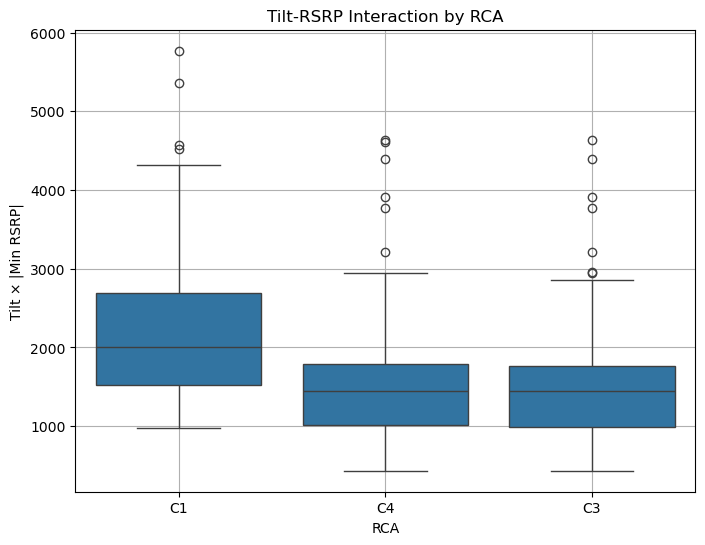

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C3", "C4"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

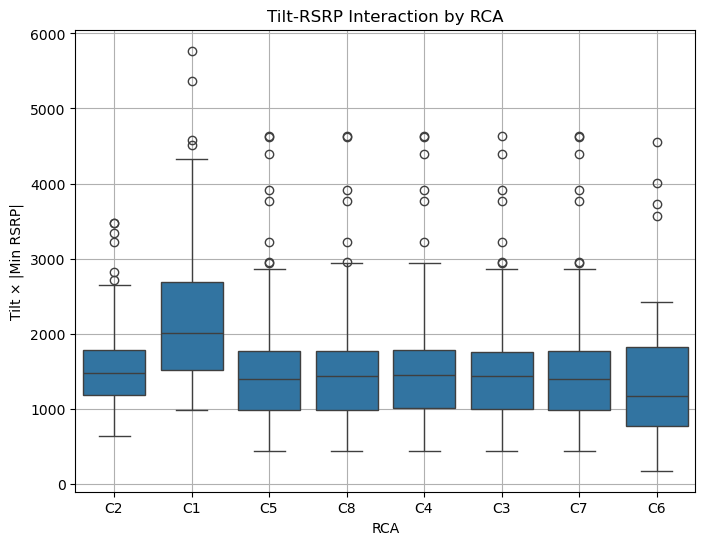

In [11]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

In [12]:
print(
    ml_df["min_rsrp"].describe()
)

count    2400.000000
mean      -88.591342
std         1.597387
min       -94.720000
25%       -89.350000
50%       -88.630000
75%       -87.610000
max       -85.000000
Name: min_rsrp, dtype: float64


C1 showed noticeably higher tilt-RSRP interaction values
Better separation was observed between C1 and neighboring-cell related issues (C3/C4)
Min rsrp are negative values. The higher absolute of min_rsrp value the it means it actually had the lowest rsrp which means the lowest signal.


## C3 vs C4

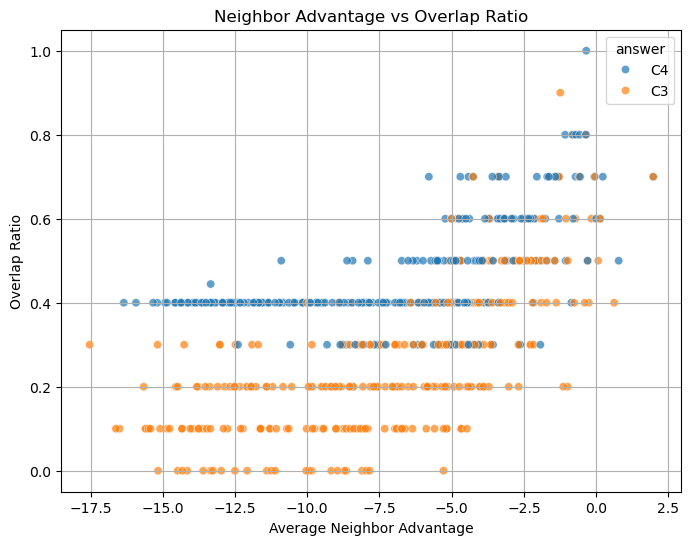

In [83]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=subset,
    x="avg_neighbor_advantage",
    y="overlap_ratio",
    hue="answer",
    alpha=0.7
)

plt.title(
    "Neighbor Advantage vs Overlap Ratio"
)
plt.xlabel(
    "Average Neighbor Advantage"
)
plt.ylabel(
    "Overlap Ratio"
)

plt.grid(True)
plt.show()

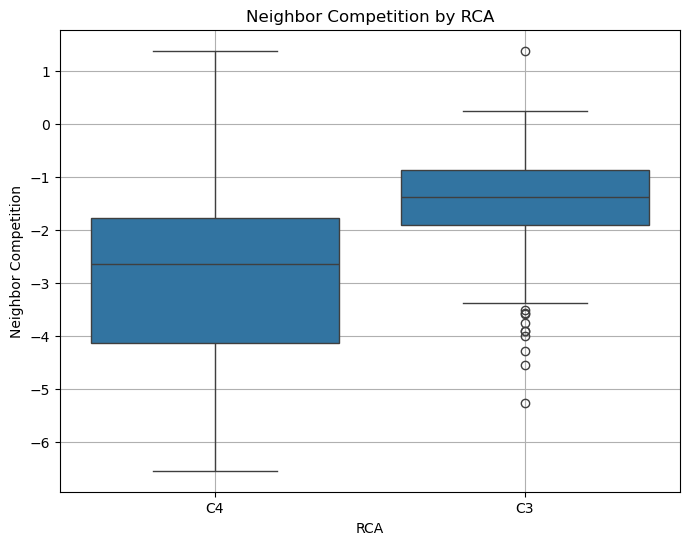

In [84]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

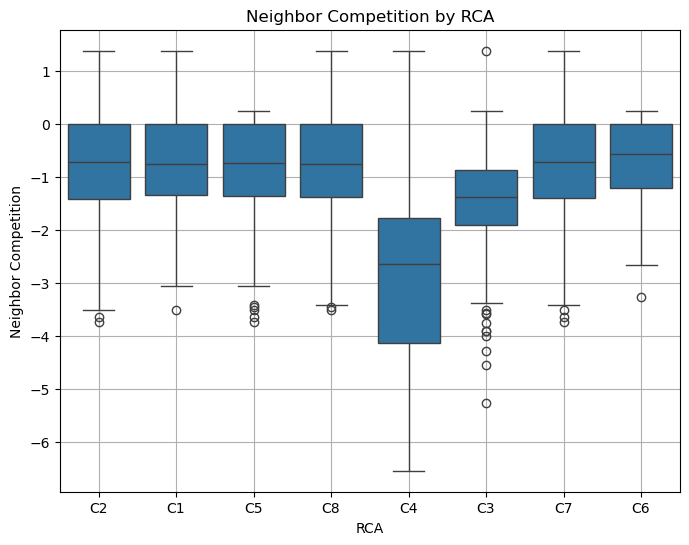

In [85]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

C4: was overlapping from neiboring cells
much lower (more negative)
neighbor competition


* C4 demonstrated the strongest overlap-driven neighbor interaction, supporting its interpretation as a severe co-frequency overlap issue.
* C3 exhibited moderate neighbor competition, aligning with a stronger neighboring-cell scenario rather than widespread interference.
* Neighbor competition showed improved class-specific separation for C3/C4 compared with other RCA classes, suggesting potential value for reducing model confusion between neighboring-cell-related failures.

## Data Preparation

### Seperate Explanatory variables and a Target Variable

In [57]:
X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

In [58]:
from sklearn.impute import SimpleImputer
import pandas as pd

# -----------------------------
# Numeric & categorical split
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# Numeric
num_imputer = SimpleImputer(strategy="median")

X_numeric = pd.DataFrame(
    num_imputer.fit_transform(X[numeric_cols]),
    columns=numeric_cols,
    index=X.index
)

# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")

X_categorical = pd.DataFrame(
    cat_imputer.fit_transform(X[categorical_cols]),
    columns=categorical_cols,
    index=X.index
)

# Combine
X_imputed = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

X_imputed

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,tilt_rsrp_interaction,txrx_mode,antenna_model
0,847.792,334.00,407.163069,4.0,0.4,424.7125,4.0,33.0,0.0,12.75,...,14.0,6.0,14.88,1.122599,2.774421,0.4,2.771672,1164.372,64T64R,NR AAU 2
1,850.051,388.58,345.211857,4.0,0.4,470.3825,4.0,33.0,0.0,12.75,...,53.0,6.0,27.84,0.047804,0.068577,0.0,0.044401,2445.844,64T64R,NR AAU 2
2,671.739,258.08,295.071300,4.0,0.4,338.5225,4.0,36.0,0.0,16.00,...,27.0,8.4,32.40,0.769140,1.698408,0.4,1.698408,1671.780,32T32R,NR AAU 3
3,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,25.54,1.295369,2.976701,0.4,2.957331,1090.680,64T64R,NR AAU 2
4,789.406,319.87,366.988478,4.0,0.4,404.2275,4.0,32.0,0.0,22.75,...,26.0,15.5,11.75,0.192364,0.263115,0.0,0.183851,1196.300,64T64R,NR AAU 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4.0,0.4,386.1975,4.0,31.0,0.0,15.00,...,22.0,10.2,23.37,0.115415,0.141225,0.0,0.126174,1329.750,64T64R,NR AAU 2
2396,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,34.36,0.188000,0.314276,0.0,0.207184,1448.280,64T64R,NR AAU 2
2397,644.153,325.71,265.283421,4.0,0.4,340.1050,4.0,36.0,0.0,20.25,...,27.0,6.0,52.36,0.126494,0.207267,0.0,0.149572,2045.967,32T32R,NR AAU 3
2398,728.994,117.97,395.994842,4.0,0.4,312.5125,4.0,38.0,0.0,7.00,...,27.0,12.0,48.50,0.192103,0.240620,0.0,0.211130,2391.402,64T64R,NR AAU 2


### One Hot Encoding for Categorical Variables

In [59]:
X_encoded = pd.get_dummies(
    X_imputed,
    drop_first=True
)

print(X_encoded.shape)

(2400, 50)


### Test/Train split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 3. XGBoost
### XGBoost - Grid Search

In [132]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [93]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score

# -----------------------------
# X and y
# -----------------------------

X = X_encoded.copy()
y = ml_df["answer"]

# -----------------------------
# Encode target labels
# C1, C2, ... -> 0, 1, ...
# -----------------------------

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(original, "->", encoded)

# -----------------------------
# Train/Test split
# -----------------------------
# If you already have X_train, X_test, y_train, y_test from before,
# you can skip this and just encode y_train/y_test.
# But this keeps it clean.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -----------------------------
# XGBoost model
# -----------------------------

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1
)


# -----------------------------
# CV setup
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

# Macro F1 scorer
f1_macro_scorer = make_scorer(
    f1_score,
    average="macro"
)

# -----------------------------
# GridSearchCV
# -----------------------------

param_grid = {
    "n_estimators": [150, 155, 160],
    "max_depth": [5, 6, 7],
    "learning_rate": [0.15, 0.17, 0.19, 0.20],
    "subsample": [ 0.9, 1.0],
    "colsample_bytree": [0.9,1.0]
}



xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("\nBest CV Macro F1:")
print(xgb_grid.best_score_)

Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7
Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0.15, max_depth=5, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.9, learning_rate=0

{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1.0}

Best CV Macro F1:
0.9578418411975405




### Fit XGBoost Model with best Parameters

In [94]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=1.0,
    learning_rate=0.15,
    max_depth=5,
    n_estimators=150,
    subsample=1.0,
    random_state=42,
    n_jobs=1
)

best_xgb.fit(X_train, y_train)

xgb_preds = best_xgb.predict(X_test)
xgb_probs = best_xgb.predict_proba(X_test)

In [95]:
y_test_labels = label_encoder.inverse_transform(y_test)
xgb_pred_labels = label_encoder.inverse_transform(xgb_preds)

### XGBoost Evaluation Metrics

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

xgb_accuracy = accuracy_score(y_test, xgb_preds)

xgb_precision = precision_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_recall = recall_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_f1 = f1_score(
    y_test,
    xgb_preds,
    average="macro"
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probs,
    multi_class="ovr",
    average="macro"
)

print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1:", xgb_f1)
print("ROC-AUC:", xgb_roc_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_test_labels,
        xgb_pred_labels
    )
)

XGBoost Results
Accuracy: 0.95625
Precision: 0.9589850019155303
Recall: 0.9549140862447715
F1: 0.9564165837441334
ROC-AUC: 0.9974431095013048

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.91      0.94        53
          C2       1.00      1.00      1.00        64
          C3       0.82      0.91      0.86        66
          C4       0.87      0.82      0.85        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.96       480
   macro avg       0.96      0.95      0.96       480
weighted avg       0.96      0.96      0.96       480



### XGBoost - Confusion Metrics

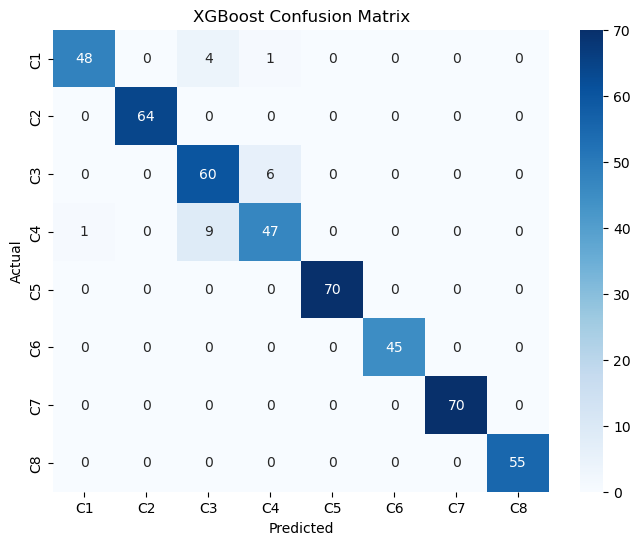

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_cm = confusion_matrix(
    y_test_labels,
    xgb_pred_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [99]:
import pandas as pd
from sklearn.metrics import confusion_matrix

xgb_youden_results = []

for cls in label_encoder.classes_:
    y_true_binary = (y_test_labels == cls).astype(int)
    y_pred_binary = (xgb_pred_labels == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    xgb_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

xgb_youden_df = pd.DataFrame(xgb_youden_results)

display(
    xgb_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.906,0.998,0.903
2,C3,0.909,0.969,0.878
3,C4,0.825,0.983,0.808


### XGBoost - Feature Importance

In [100]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(xgb_feature_importance.head(20))

,feature,importance
11,num_unique_serving_pci,0.237656
12,handover_count,0.149833
35,same_mod30_count,0.130872
7,max_speed,0.125267
24,avg_rb,0.092346
16,min_rsrp,0.055113
3,low_tp_count,0.029474
33,overlap_ratio,0.021889
31,neighbor_stronger_ratio,0.020893
14,handover_count_low_tp,0.016000


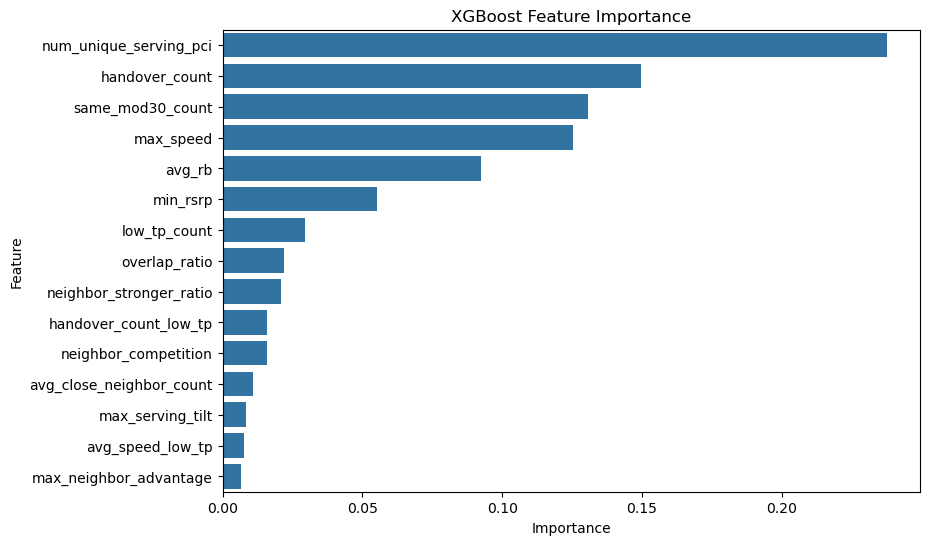

In [101]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### XGBoost - ROC Curve — Multiclass One-vs-Rest

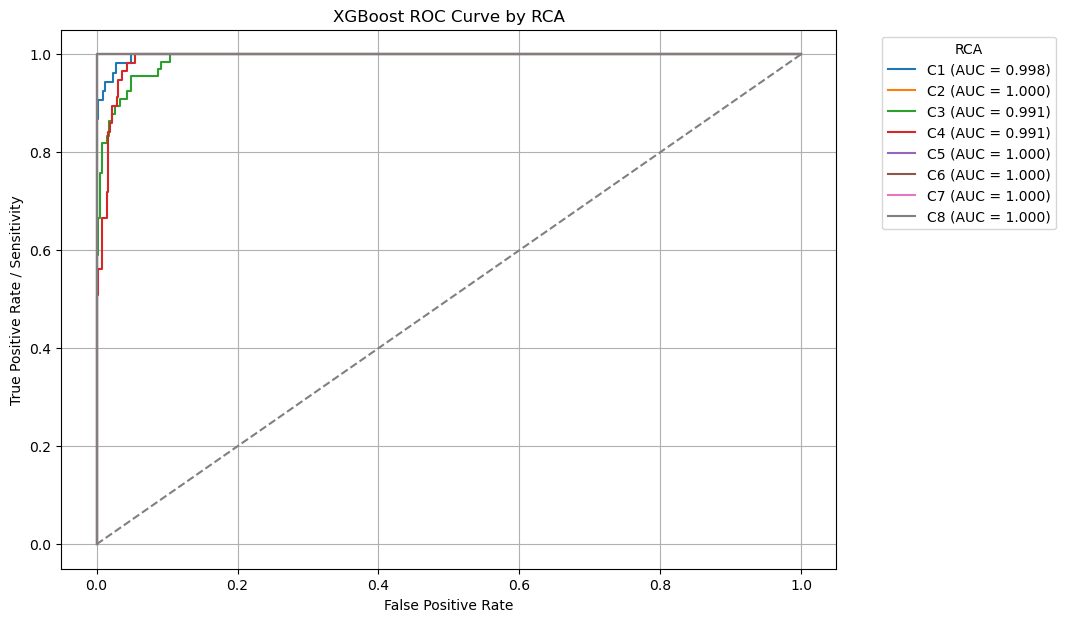

In [102]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = label_encoder.classes_

y_test_bin = label_binarize(
    y_test_labels,
    classes=classes
)

plt.figure(figsize=(10,7))

xgb_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    xgb_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("XGBoost ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### XGBoost Precision-Recall Curve — Multiclass One-vs-Rest

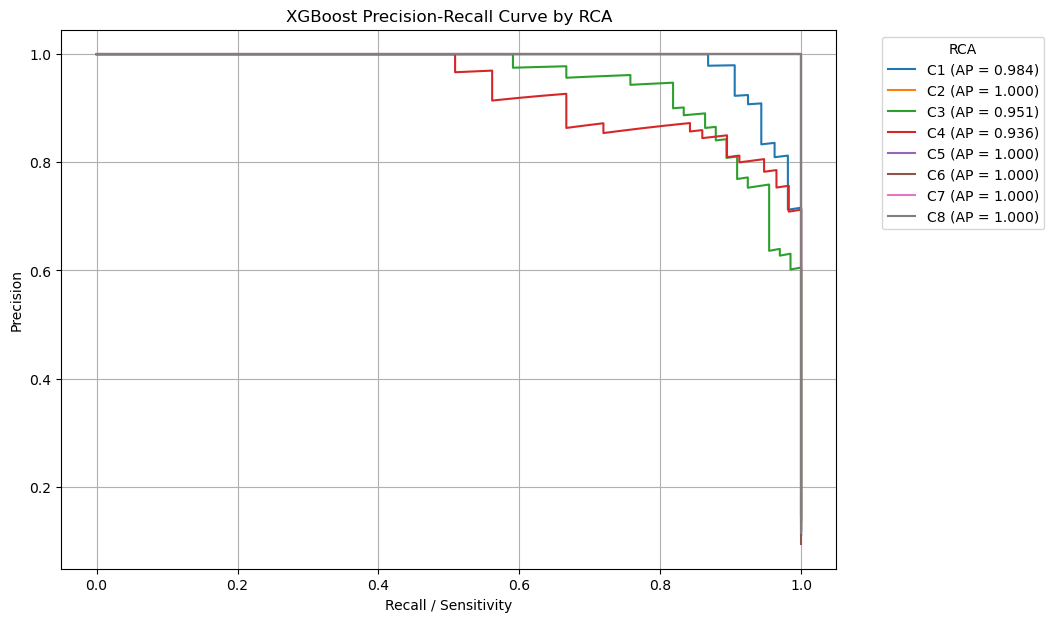

In [103]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

xgb_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    xgb_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("XGBoost Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### Internal 5-fold Cross Validaton

In [104]:
from sklearn.model_selection import StratifiedKFold, cross_validate

xgb_cv_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=1.0,
    learning_rate=0.15,
    max_depth=5,
    n_estimators=150,
    subsample=1.0,
    random_state=42,
    n_jobs=1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_encoded,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = xgb_cv_results[f"train_{metric}"]
    test_scores = xgb_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {train_scores.mean():.3f} ({train_scores.std():.3f})")
    print(f"  Test : {test_scores.mean():.3f} ({test_scores.std():.3f})")
    print("-" * 40)

accuracy
  Train: 1.000 (0.000)
  Test : 0.956 (0.007)
----------------------------------------
precision_macro
  Train: 1.000 (0.000)
  Test : 0.958 (0.007)
----------------------------------------
recall_macro
  Train: 1.000 (0.000)
  Test : 0.955 (0.006)
----------------------------------------
f1_macro
  Train: 1.000 (0.000)
  Test : 0.956 (0.007)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.998 (0.000)
----------------------------------------


| Model               |  Accuracy | Precision Macro | Recall Macro |  F1 Macro |   ROC-AUC |
| ------------------- | --------: | --------------: | -----------: | --------: | --------: |
| Logistic Regression |     0.946 |           0.946 |        0.945 |     0.945 |     0.996 |
| Random Forest       |     0.944 |           0.946 |        0.943 |     0.944 |     0.996 |
| **XGBoost**         | **0.954** |       **0.957** |    **0.953** | **0.954** | **0.998** |


**Key observations:**

XGBoost improved overall performance, especially Macro F1: 0.954 vs. 0.945 for Logistic Regression.
C2, C5, C6, C7, and C8 were perfectly classified, which matches your EDA and SHAP findings.
C3 and C4 are still the hardest classes, but XGBoost improved C3 recall to 0.894 and C3 F1 to 0.86.
The confusion is still mainly C3 ↔ C4, suggesting these two RCA types have genuinely overlapping KPI signatures.
CV test Macro F1 = 0.955, which matches the holdout result very well.
Train CV = 1.000, so XGBoost is fitting training data perfectly, but the stable test CV suggests performance is still strong. I would describe this as high model capacity with good validation performance, not a failure.

XGBoost achieved the strongest overall performance, suggesting that nonlinear boosted trees can capture additional RCA structure beyond Logistic Regression and Random Forest, especially for more ambiguous classes such as C3 and C4. However, the remaining C3/C4 confusion indicates that these RCA mechanisms may share similar telecom KPI patterns.

### XGBoost - External Cross Valdation

In [105]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode RCA labels using FULL train.json
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(original, "->", encoded)

# -----------------------------
# Refit XGBoost on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y_encoded.copy()

best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=1.0,
    learning_rate=0.15,
    max_depth=5,
    n_estimators=150,
    subsample=1.0,
    random_state=42,
    n_jobs=1
)

best_xgb.fit(
    X_full_train,
    y_full_train
)

print("Final XGBoost model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7
Final XGBoost model refit on 100% of train.json
Training shape: (2400, 50)


In [107]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# External X data should already be prepared:
# - one-hot encoded
# - reindexed to X_train.columns
# - median imputed
# - NOT scaled

X_test_external_xgb = X_test_external.copy()

# Encode external y labels using the SAME label encoder
y_test_external_encoded = label_encoder.transform(y_test_external)

# Predict
xgb_external_preds_encoded = best_xgb.predict(X_test_external_xgb)
xgb_external_probs = best_xgb.predict_proba(X_test_external_xgb)

# Convert predictions back to original labels
xgb_external_preds = label_encoder.inverse_transform(
    xgb_external_preds_encoded.astype(int)
)

# Evaluation
print("XGBoost External Test Accuracy:")
print(accuracy_score(y_test_external, xgb_external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, xgb_external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, xgb_external_preds))

XGBoost External Test Accuracy:
0.8229166666666666

Confusion Matrix:
[[ 82   0   9   4   0   0   0  13]
 [  0  85   0   0   0   0   0  23]
 [  1   0  81   3   0   0   0  23]
 [  3   0  15  68   0   0   0  22]
 [  0   0   0   0  85   0   0  23]
 [  0   0   0   0   0  94   0  14]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.95      0.76      0.85       108
          C2       1.00      0.79      0.88       108
          C3       0.77      0.75      0.76       108
          C4       0.91      0.63      0.74       108
          C5       1.00      0.79      0.88       108
          C6       1.00      0.87      0.93       108
          C7       1.00      1.00      1.00       108
          C8       0.48      1.00      0.65       108

    accuracy                           0.82       864
   macro avg       0.89      0.82      0.84       864
weighted avg       0.89      

In [108]:
xgb_report = classification_report(
    y_test_external,
    xgb_external_preds,
    output_dict=True
)

xgb_metrics_df = pd.DataFrame(xgb_report).transpose().round(3)
xgb_metrics_df

,precision,recall,f1-score,support
C1,0.953,0.759,0.845,108.000
C2,1.000,0.787,0.881,108.000
C3,0.771,0.750,0.761,108.000
C4,0.907,0.630,0.743,108.000
C5,1.000,0.787,0.881,108.000
C6,1.000,0.870,0.931,108.000
C7,1.000,1.000,1.000,108.000
C8,0.478,1.000,0.647,108.000
accuracy,0.823,0.823,0.823,0.823
macro avg,0.889,0.823,0.836,864.000


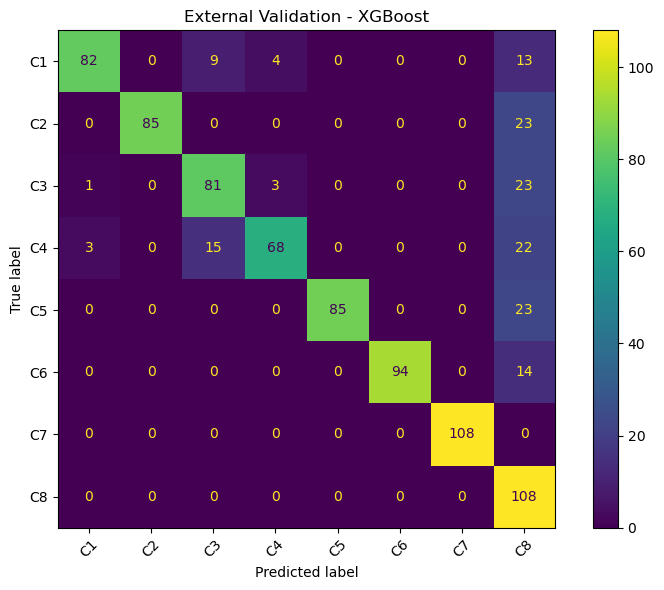

In [109]:
cm = confusion_matrix(y_test_external, xgb_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - XGBoost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()